Goal: Predict sales prices and practice feature engineering, RFs, and gradient boosting

1. Creative feature engineering 
2. Advanced regression techniques like random forest and gradient boosting

Submission Format:
Id,SalePrice
1461,169000.1
1462,187724.1233
1463,175221
etc.

Notes:
1. Exclude outliers
2. Preprocess = dups, missing val, inconsistent 

Algorithm/Psuedocode
1. Normalization (Min Max Scale)
2. nd exclusion of outliers

(ALSO PRACTICE)


In [169]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
# from catboost import CatBoopython
import lightgbm as lgb

In [170]:
df = pd.read_csv("../data/train.csv")


In [171]:
num_of_columns = df.columns
print(f"Num of columns: {len(num_of_columns)}")
num_of_columns


Num of columns: 81


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [172]:
df = df.drop(['Id'], axis=1)
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


LotArea


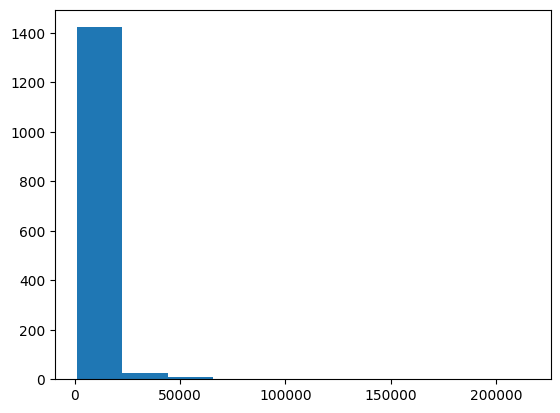

Sale Price


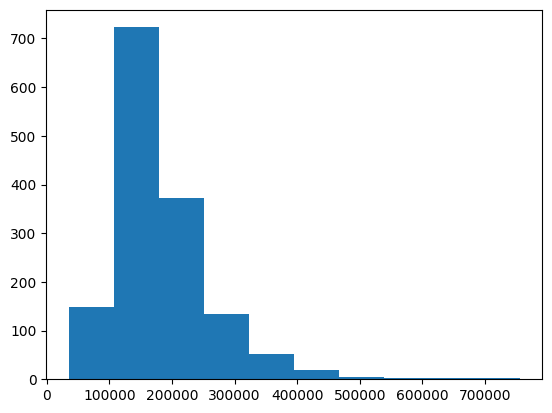

Overall quality


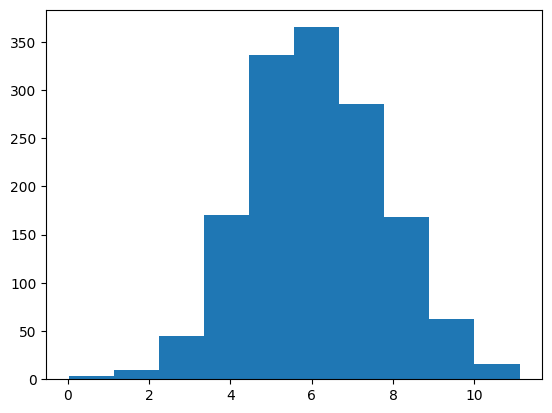

In [173]:
#Visualization for lotarea
lot_area = np.random.normal(df["LotArea"])
print("LotArea")
plt.hist(lot_area)
plt.show()

#Visualization for sale price
sale_price = np.random.normal(df["SalePrice"])
print("Sale Price")
plt.hist(sale_price)
plt.show()

#Overall quality (ordinal)
overal_quality = np.random.normal(df["OverallQual"])
print("Overall quality")
plt.hist(overal_quality)
plt.show()

LotFrontage


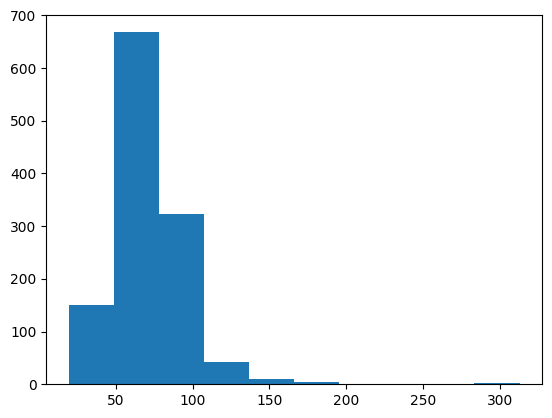

In [174]:
LotFrontage = np.random.normal(df["LotFrontage"])
print("LotFrontage")
plt.hist(LotFrontage)
plt.show()

MasVnrArea


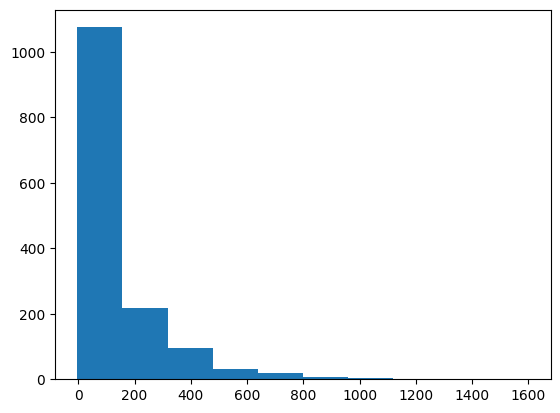

In [175]:
MasVnrArea = np.random.normal(df["MasVnrArea"])
print("MasVnrArea")
plt.hist(MasVnrArea)
plt.show()

In [187]:
missing_values = df.isnull().sum()
print(missing_values[missing_values>0])
    

Series([], dtype: int64)


<Axes: >

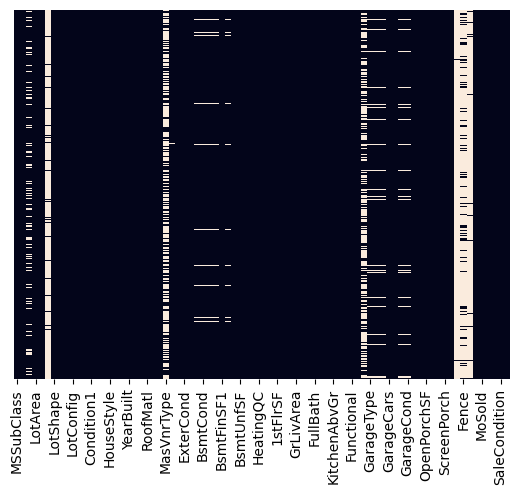

In [177]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [179]:
df.drop(["LotShape","Fence","PoolQC","MiscFeature","Alley"], axis=1, inplace=True)

In [180]:
#Fill missing values
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

In [181]:
df["BsmtCond"]=df["BsmtCond"].fillna(df["BsmtCond"].mode()[0])
df["BsmtQual"]=df["BsmtQual"].fillna(df["BsmtQual"].mode()[0])

In [182]:
df["FireplaceQu"] = df["FireplaceQu"].fillna(df["FireplaceQu"].mode()[0])
df["GarageType"] = df["GarageType"].fillna(df["GarageType"].mode()[0])

In [183]:
df["LotFrontage"]= df["LotFrontage"].fillna(df["LotFrontage"].mean())

In [184]:
#Got lazy so here's a loop to handle missing values on QL data
cat_col = df.select_dtypes(include="object").columns.tolist()

for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [185]:
df["MasVnrArea"]= df["MasVnrArea"].fillna(df["MasVnrArea"].median())
df["GarageYrBlt"]= df["GarageYrBlt"].fillna(df["GarageYrBlt"].median())

In [ ]:
# #Feature engineering

# #Month Sold + Year Sold
# df["DateSold"] = pd.to_datetime(df["YrSold"].astype(str) + "-" + df["MoSold"].astype(str), format="%Y-%m")
# df = df.drop(["YrSold","MoSold"], axis=1)

# #total porch area
# df["TotalPorchArea"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
# df = df.drop(["OpenPorchSF","EnclosedPorch","3SsnPorch","ScreenPorch"],axis=1)